In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("CampusPulse analysis started 🚀")

Matplotlib is building the font cache; this may take a moment.


CampusPulse analysis started 🚀


In [2]:
from ucimlrepo import fetch_ucirepo

# Download the dataset from UCI
student_data = fetch_ucirepo(id=856)

# Separate input features and target
X = student_data.data.features
y = student_data.data.targets

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (145, 31)
Target shape: (145, 1)


In [3]:
X.head()

,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Attendance to classes,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID
0,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,1,2,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,1,3,2,3,2,2,3,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,1,2,2,1,1,2,2,1
3,1,1,1,3,1,2,1,2,1,2,...,1,1,2,3,2,2,1,3,2,1
4,2,2,1,3,2,2,1,3,1,4,...,1,2,1,2,2,2,1,2,2,1


In [4]:
y.head()

,OUTPUT Grade
0,1
1,1
2,1
3,1
4,1


In [5]:
print(X.columns.tolist())

['Student Age', 'Sex', 'Graduated high-school type', 'Scholarship type', 'Additional work', 'Regular artistic or sports activity', 'Do you have a partner', 'Total salary if available', 'Transportation to the university', 'Accomodation type in Cyprus', "Mother's education", "Father's education", 'Number of sisters/brothers (if available)', 'Parental status', "Mother's occupation", "Father's occupation", 'Weekly study hours', 'Reading frequency (non-scientific books/journals)', 'Reading frequency (scientific books/journals)', 'Attendance to the seminars/conferences related to the department', 'Impact of your projects/activities on your success', 'Attendance to classes', 'Preparation to midterm exams 1', 'Preparation to midterm exams 2', 'Taking notes in classes', 'Listening in classes', 'Discussion improves my interest and success in the course', 'Flip-classroom', 'Cumulative grade point average in the last semester (/4.00)', 'Expected Cumulative grade point average in the graduation (/4

In [6]:
student_data.variables

,name,role,type,demographic,description,units,missing_values
0,Student Age,Feature,Categorical,Age,"1: 18-21, 2: 22-25, 3: above 26",None,no
1,Sex,Feature,Binary,Sex,"1: female, 2: male",None,no
2,Graduated high-school type,Feature,Categorical,Education Level,"1: private, 2: state, 3: other",None,no
3,Scholarship type,Feature,Categorical,NaN,"1: None, 2: 25%, 3: 50%, 4: 75%, 5: Full",None,no
4,Additional work,Feature,Binary,NaN,"1: Yes, 2: No",None,no
5,Regular artistic or sports activity,Feature,Binary,NaN,"1: Yes, 2: No",None,no
6,Do you have a partner,Feature,Binary,Marital Status,"1: Yes, 2: No",None,no
7,Total salary if available,Feature,Categorical,Income,"1: USD 135-200, 2: USD 201-270, 3: USD 271-340...",None,no
8,Transportation to the university,Feature,Categorical,NaN,"1: Bus, 2: Private car/taxi, 3: bicycle, 4: Other",None,no
9,Accomodation type in Cyprus,Feature,Categorical,NaN,"1: rental, 2: dormitory, 3: with family, 4: Other",None,no


In [7]:
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 31 columns):
 #   Column                                                             Non-Null Count  Dtype
---  ------                                                             --------------  -----
 0   Student Age                                                        145 non-null    int64
 1   Sex                                                                145 non-null    int64
 2   Graduated high-school type                                         145 non-null    int64
 3   Scholarship type                                                   145 non-null    int64
 4   Additional work                                                    145 non-null    int64
 5   Regular artistic or sports activity                                145 non-null    int64
 6   Do you have a partner                                              145 non-null    int64
 7   Total salary if available                              

In [8]:
X.isnull().sum()

Student Age                                                          0
Sex                                                                  0
Graduated high-school type                                           0
Scholarship type                                                     0
Additional work                                                      0
Regular artistic or sports activity                                  0
Do you have a partner                                                0
Total salary if available                                            0
Transportation to the university                                     0
Accomodation type in Cyprus                                          0
Mother's education                                                   0
Father's education                                                   0
Number of sisters/brothers (if available)                            0
Parental status                                                      0
Mother

In [9]:
X.duplicated().sum()

np.int64(0)

In [10]:
y.value_counts()

OUTPUT Grade
1               35
2               24
3               21
5               17
7               17
6               13
4               10
0                8
Name: count, dtype: int64

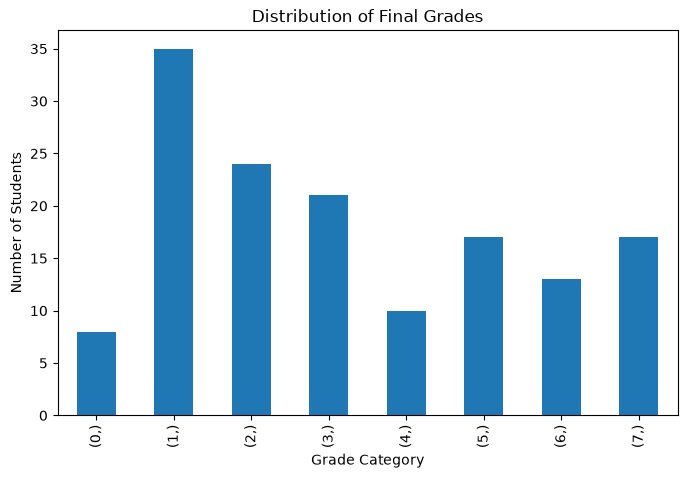

In [11]:
y.value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Final Grades")
plt.xlabel("Grade Category")
plt.ylabel("Number of Students")

plt.show()

In [12]:
for i, column in enumerate(X.columns):
    print(i, column)

0 Student Age
1 Sex
2 Graduated high-school type
3 Scholarship type
4 Additional work
5 Regular artistic or sports activity
6 Do you have a partner
7 Total salary if available
8 Transportation to the university
9 Accomodation type in Cyprus
10 Mother's education
11 Father's education
12 Number of sisters/brothers (if available)
13 Parental status
14 Mother's occupation
15 Father's occupation
16 Weekly study hours
17 Reading frequency (non-scientific books/journals)
18 Reading frequency (scientific books/journals)
19 Attendance to the seminars/conferences related to the department
20 Impact of your projects/activities on your success
21 Attendance to classes
22 Preparation to midterm exams 1
23 Preparation to midterm exams 2
24 Taking notes in classes
25 Listening in classes
26 Discussion improves my interest and success in the course
27 Flip-classroom
28 Cumulative grade point average in the last semester (/4.00)
29 Expected Cumulative grade point average in the graduation (/4.00)
30 C

In [13]:
df = X.copy()

df["GRADE"] = y.values.ravel()

df.head()

,Student Age,Sex,Graduated high-school type,Scholarship type,Additional work,Regular artistic or sports activity,Do you have a partner,Total salary if available,Transportation to the university,Accomodation type in Cyprus,...,Preparation to midterm exams 1,Preparation to midterm exams 2,Taking notes in classes,Listening in classes,Discussion improves my interest and success in the course,Flip-classroom,Cumulative grade point average in the last semester (/4.00),Expected Cumulative grade point average in the graduation (/4.00),Course ID,GRADE
0,2,2,3,3,1,2,2,1,1,1,...,1,1,3,2,1,2,1,1,1,1
1,2,2,3,3,1,2,2,1,1,1,...,1,1,3,2,3,2,2,3,1,1
2,2,2,2,3,2,2,2,2,4,2,...,1,1,2,2,1,1,2,2,1,1
3,1,1,1,3,1,2,1,2,1,2,...,1,2,3,2,2,1,3,2,1,1
4,2,2,1,3,2,2,1,3,1,4,...,2,1,2,2,2,1,2,2,1,1


In [14]:
top_correlations = (
    correlations
    .drop("GRADE")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_correlations

NameError: name 'correlations' is not defined

In [15]:
correlations = df.corr(numeric_only=True)["GRADE"]

correlations.sort_values(ascending=False)

GRADE                                                                1.000000
Sex                                                                  0.335533
Cumulative grade point average in the last semester (/4.00)          0.315493
Expected Cumulative grade point average in the graduation (/4.00)    0.248588
Reading frequency (non-scientific books/journals)                    0.195617
Additional work                                                      0.167445
Discussion improves my interest and success in the course            0.146547
Course ID                                                            0.142166
Flip-classroom                                                       0.110617
Graduated high-school type                                           0.104821
Listening in classes                                                 0.085137
Number of sisters/brothers (if available)                            0.084470
Preparation to midterm exams 2                                  

In [16]:
top_correlations = (
    correlations
    .drop("GRADE")
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

top_correlations

Sex                                                                  0.335533
Cumulative grade point average in the last semester (/4.00)          0.315493
Expected Cumulative grade point average in the graduation (/4.00)    0.248588
Impact of your projects/activities on your success                   0.203273
Reading frequency (non-scientific books/journals)                    0.195617
Attendance to the seminars/conferences related to the department     0.184763
Additional work                                                      0.167445
Total salary if available                                            0.166352
Transportation to the university                                     0.156289
Discussion improves my interest and success in the course            0.146547
Name: GRADE, dtype: float64

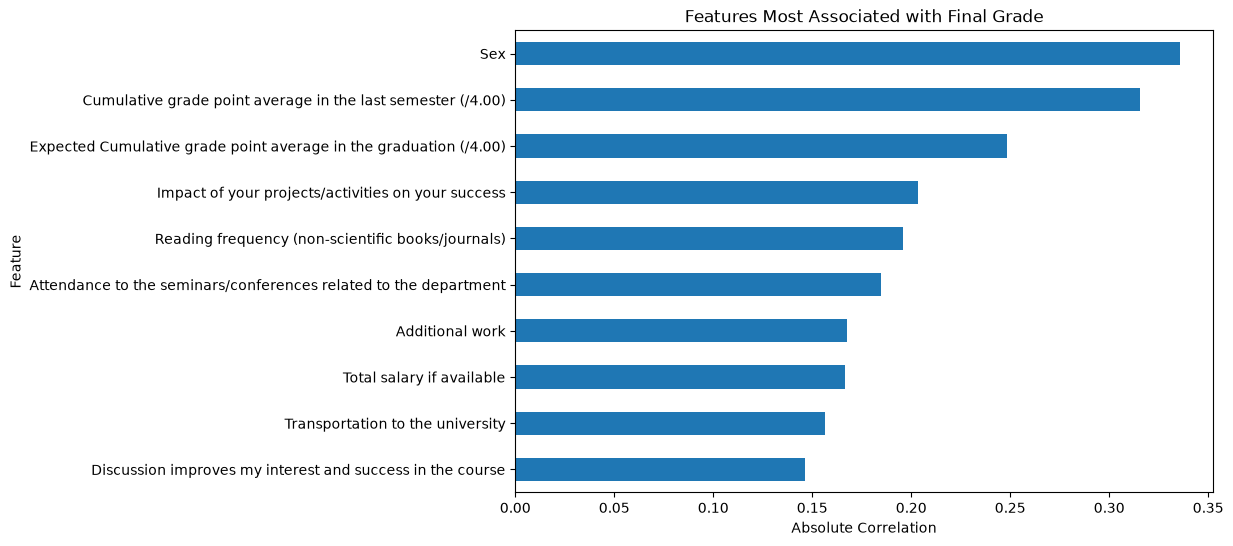

In [17]:
top_correlations.sort_values().plot(
    kind="barh",
    figsize=(9, 6)
)

plt.title("Features Most Associated with Final Grade")
plt.xlabel("Absolute Correlation")
plt.ylabel("Feature")

plt.show()